# ⛈️ Thunderstorm Forecasting System
## End-to-End ML Pipeline with MLflow (DagsHub) + Streamlit

**Project Structure (Colab):**
```
/content/thunderstorm_forecasting/
├── data/
│   └── processed/    ← merged_df_all12k_combined.csv  (upload this one file)
├── models/           ← KNN_best_model.pkl, best_model_Random_Forest.pkl, scaler.pkl
├── streamlit_app/    ← ui.py  (served via ngrok)
├── api/              ← main.py (FastAPI)
└── outputs/          ← plots, model_comparison.csv
```
**Stack:** Pandas · Scikit-learn · Imbalanced-learn (SMOTE) · MLflow · DagsHub · Streamlit · ngrok

> **Only 1 CSV needed:** `merged_df_all12k_combined.csv` — the pre-merged processed dataset.

## 📦 Step 0 — Install Dependencies

In [1]:
!pip install -q mlflow dagshub scikit-learn imbalanced-learn \
              streamlit pyngrok pandas numpy matplotlib seaborn joblib fastapi uvicorn
print('✅ All packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.

## 🔑 Step 1 — Environment Variables from Colab Secrets
> **Left sidebar → 🔑 Key icon → Add new secret**  
> Keys: `MONGO_DB_URL` · `MLFLOW_TRACKING_URI` · `MLFLOW_TRACKING_USERNAME` · `MLFLOW_TRACKING_PASSWORD` · `NGROK_AUTHTOKEN`

In [2]:
import os
from google.colab import userdata

os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

USE_DAGSHUB = True  # Set False → logs locally to /content/mlruns

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


## 📁 Step 2 — Project Directory Setup

In [3]:
import os

BASE_DIR = '/content/thunderstorm_forecasting'

dirs = [
    f'{BASE_DIR}/data/processed',
    f'{BASE_DIR}/models',
    f'{BASE_DIR}/streamlit_app',
    f'{BASE_DIR}/api',
    f'{BASE_DIR}/outputs',
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print('✅ Directories ready:')
for d in dirs: print(f'   {d}')

✅ Directories ready:
   /content/thunderstorm_forecasting/data/processed
   /content/thunderstorm_forecasting/models
   /content/thunderstorm_forecasting/streamlit_app
   /content/thunderstorm_forecasting/api
   /content/thunderstorm_forecasting/outputs


## 📂 Step 3 — Upload Processed Dataset
Upload **one file only:** `merged_df_all12k_combined.csv`

This is the pre-merged dataset (indices + surface data with TH target) — found in `data/processed/` from the project ZIP.

In [4]:
from google.colab import files

print('📎 Upload: merged_df_all12k_combined.csv')
uploaded = files.upload()

for fname, data in uploaded.items():
    dest = f'{BASE_DIR}/data/processed/{fname}'
    with open(dest, 'wb') as f:
        f.write(data)
    print(f'✅ Saved → {dest}')

PROCESSED_CSV = f'{BASE_DIR}/data/processed/merged_df_all12k_combined.csv'

📎 Upload: merged_df_all12k_combined.csv


Saving merged_df_all12k_combined.csv to merged_df_all12k_combined (1).csv
✅ Saved → /content/thunderstorm_forecasting/data/processed/merged_df_all12k_combined (1).csv


## 🔍 Step 4 — Load & Inspect Processed Dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Correct the path for PROCESSED_CSV to match the uploaded file name
PROCESSED_CSV = '/content/thunderstorm_forecasting/data/processed/merged_df_all12k_combined (1).csv'
df = pd.read_csv(PROCESSED_CSV)

# ── Ensure TH is integer ──────────────────────────────────────────
df['TH'] = pd.to_numeric(df['TH'], errors='coerce').fillna(0).astype(int)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nTarget (TH) distribution:')
print(df['TH'].value_counts())
print(f'\nNull counts:')
print(df.isnull().sum()[df.isnull().sum() > 0])
display(df.head(5))

Shape: (11873, 19)
Columns: ['Year', 'Month', 'Day', 'Hour', 'GMT', 'SWEAT index', 'Showalter index', 'LIFTED index', 'K index', 'Cross totals index', 'Vertical totals index', 'Totals totals index', 'TLCL', 'PLCL', 'CINE', 'CAPE', 'PRECIPITABLE WATER', 'prob', 'TH']

Target (TH) distribution:
TH
0    11864
1        9
Name: count, dtype: int64

Null counts:
prob    11873
dtype: int64


,Year,Month,Day,Hour,GMT,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,prob,TH
0,1981,1,1,6.0,78.60,10.85,10.7,-0.70,4.60,22.2,26.80,283.080,925.035,0.0,0.0,23.75,5653.5,NaN,0
1,1981,1,2,6.0,93.70,9.35,9.4,1.20,11.65,20.1,31.75,281.275,896.195,0.0,0.0,21.70,5626.0,NaN,0
2,1981,1,3,12.0,64.00,2.10,-0.2,2.80,13.40,24.1,37.50,284.250,862.290,-260.5,0.8,19.70,5636.0,NaN,0
3,1981,1,4,6.0,113.55,4.40,3.6,14.35,15.90,26.8,42.70,283.300,904.735,0.0,0.0,21.55,5603.0,NaN,0
4,1981,1,5,6.0,176.00,1.35,-1.0,27.40,21.30,27.7,49.00,286.775,920.835,-188.0,405.7,29.70,5588.5,NaN,0


## 📊 Step 5 — Exploratory Data Analysis

df_clean shape: (11873, 13)
TH classes present: [np.int64(0), np.int64(1)]


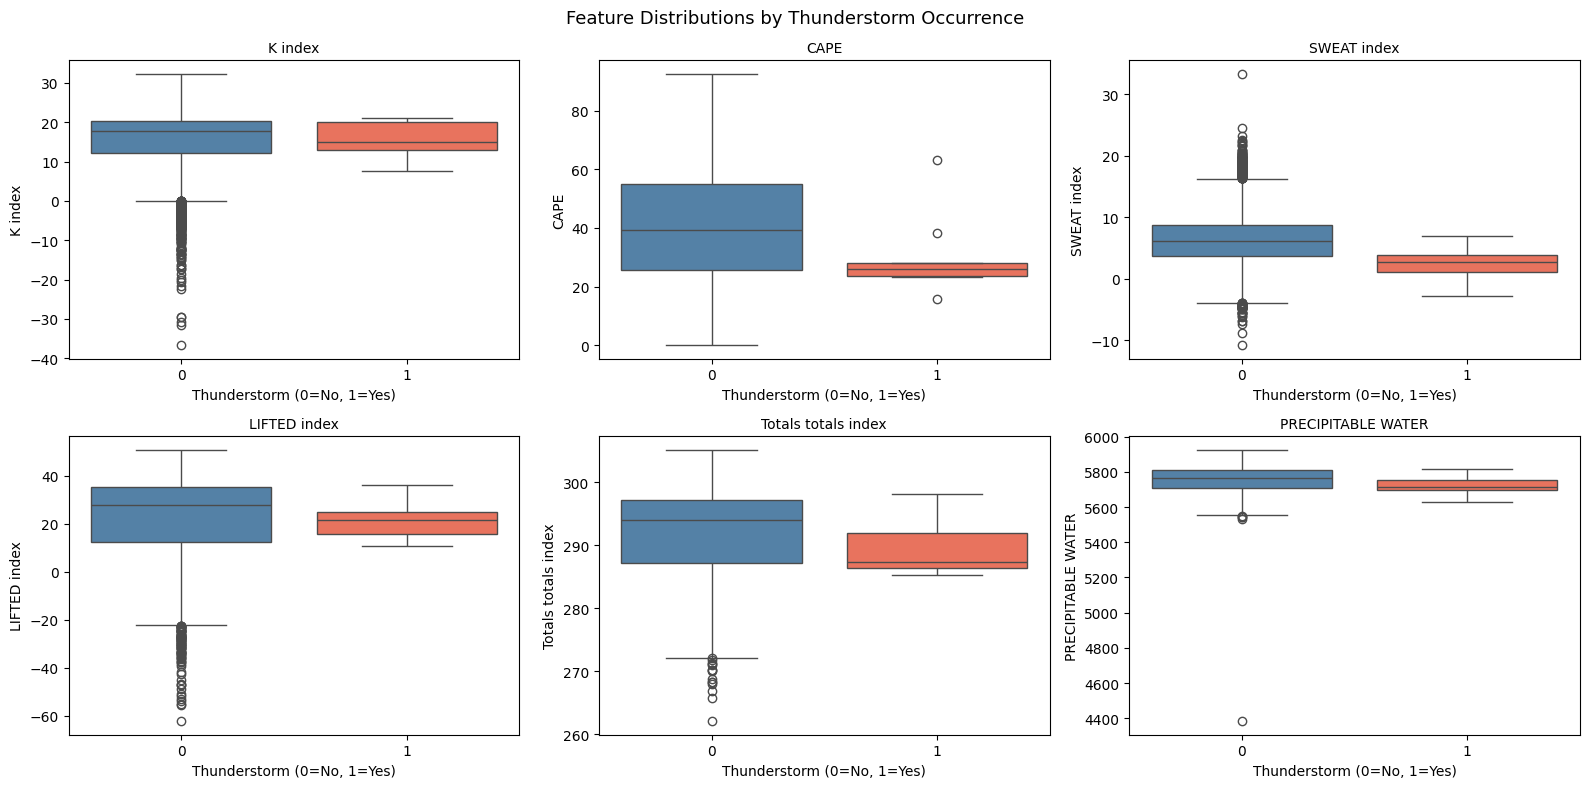

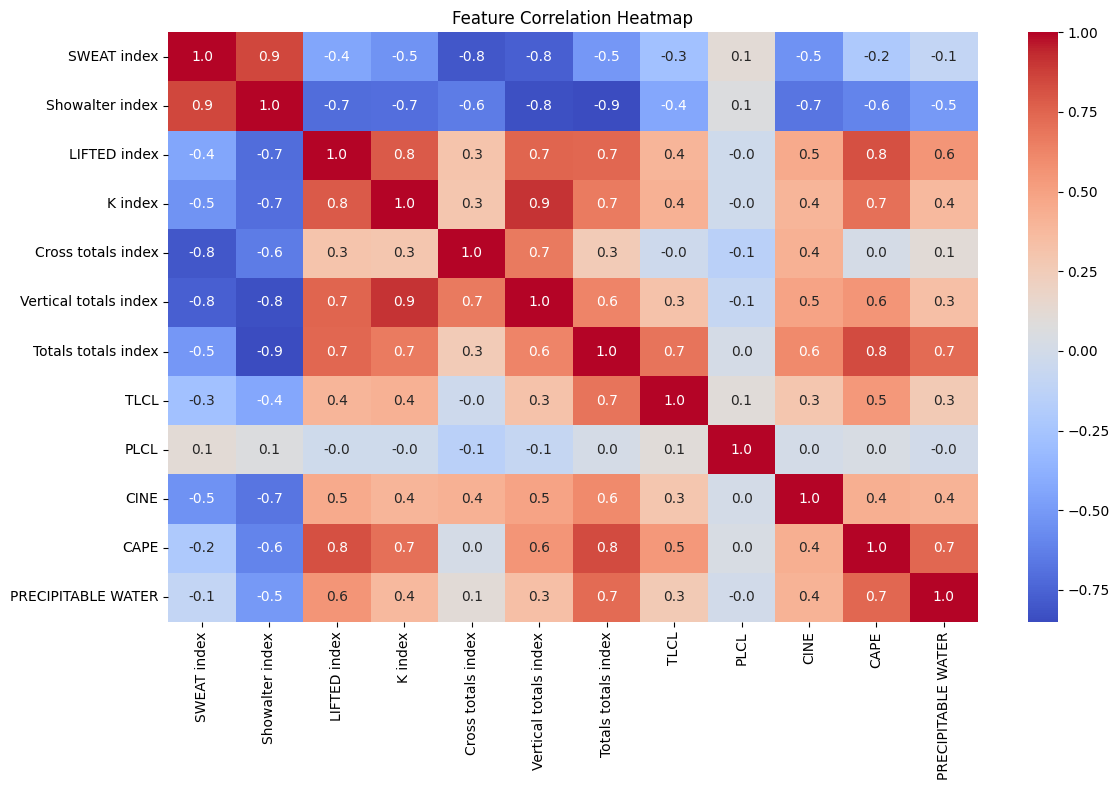

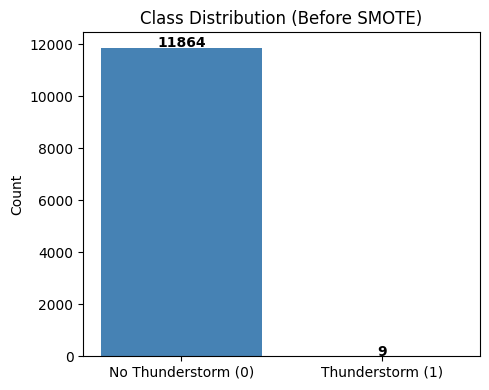

✅ EDA plots saved to outputs/


In [8]:
FEATURE_COLS = [
    'SWEAT index', 'Showalter index', 'LIFTED index', 'K index',
    'Cross totals index', 'Vertical totals index', 'Totals totals index',
    'TLCL', 'PLCL', 'CINE', 'CAPE', 'PRECIPITABLE WATER'
]
TARGET = 'TH'

df_clean = df[FEATURE_COLS + [TARGET]].dropna()
df_clean[TARGET] = df_clean[TARGET].astype(int)
print(f'df_clean shape: {df_clean.shape}')
print(f'TH classes present: {sorted(df_clean[TARGET].unique())}')

# ── Boxplots ─────────────────────────────────────────────────────
key_features = ['K index','CAPE','SWEAT index','LIFTED index','Totals totals index','PRECIPITABLE WATER']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), key_features):
    sns.boxplot(
        data=df_clean, x=TARGET, y=feat, ax=ax,
        palette={'0':'steelblue', '1':'tomato'}, # Changed keys to strings
        order=sorted(df_clean[TARGET].unique())
    )
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Thunderstorm (0=No, 1=Yes)')
plt.suptitle('Feature Distributions by Thunderstorm Occurrence', fontsize=13)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/feature_boxplots.png', dpi=100)
plt.show()

# ── Correlation heatmap ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df_clean[FEATURE_COLS].corr(), annot=True, fmt='.1f', cmap='coolwarm', ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/correlation_heatmap.png', dpi=100)
plt.show()

# ── Class distribution bar ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df_clean[TARGET].value_counts().sort_index()
bars = ax.bar(['No Thunderstorm (0)', 'Thunderstorm (1)'][:len(counts)],
              counts.values, color=['steelblue','tomato'])
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 20, str(v), ha='center', fontweight='bold')
ax.set_title('Class Distribution (Before SMOTE)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/outputs/class_distribution.png', dpi=100)
plt.show()

print('✅ EDA plots saved to outputs/')


## ⚙️ Step 6 — Train/Test Split + SMOTE + Scaling

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

df_model = df[FEATURE_COLS + [TARGET]].dropna().copy()
df_model[TARGET] = df_model[TARGET].astype(int)
X = df_model[FEATURE_COLS]
y = df_model[TARGET]

print(f'Dataset: {X.shape[0]} rows | TH dist: {dict(y.value_counts())}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

# SMOTE on train only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — Train: {X_train_res.shape[0]} | dist: {dict(pd.Series(y_train_res).value_counts())}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

import joblib
joblib.dump(scaler, f'{BASE_DIR}/models/scaler.pkl')
print('\n✅ Preprocessing complete — scaler saved')

Dataset: 11873 rows | TH dist: {0: np.int64(11864), 1: np.int64(9)}
Train: 9498  |  Test: 2375
After SMOTE — Train: 18982 | dist: {0: np.int64(9491), 1: np.int64(9491)}

✅ Preprocessing complete — scaler saved


## 🧪 Step 7 — Model Training + MLflow Tracking
Trains **Random Forest**, **KNN**, **Logistic Regression**, **Decision Tree** — each as a separate MLflow run.

In [10]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
mlflow.set_experiment('Thunderstorm_Forecasting')

MODELS = {
    'Random_Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, weights='distance'),
    'Logistic_Regression': LogisticRegression(
        max_iter=500, class_weight='balanced', random_state=42),
    'Decision_Tree': DecisionTreeClassifier(
        max_depth=8, random_state=42, class_weight='balanced'),
}

results = {}

for model_name, model in MODELS.items():
    print(f'\n🔄 Training {model_name} ...')
    with mlflow.start_run(run_name=model_name):
        mlflow.log_params(model.get_params())
        mlflow.log_param('smote', True)
        mlflow.log_param('scaler', 'StandardScaler')
        mlflow.log_param('n_features', len(FEATURE_COLS))
        mlflow.log_param('train_size', X_train_scaled.shape[0])
        mlflow.log_param('test_size',  X_test_scaled.shape[0])

        model.fit(X_train_scaled, y_train_res)
        y_pred = model.predict(X_test_scaled)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
        except Exception:
            auc = 0.0

        mlflow.log_metrics({'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,'roc_auc':auc})

        # Confusion matrix
        cm_path = f'{BASE_DIR}/outputs/cm_{model_name}.png'
        fig, ax = plt.subplots(figsize=(4,4))
        ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax)
        ax.set_title(model_name)
        plt.tight_layout(); plt.savefig(cm_path); plt.close()
        mlflow.log_artifact(cm_path)

        mlflow.sklearn.log_model(model, artifact_path='model')

        results[model_name] = {'acc':acc,'prec':prec,'rec':rec,'f1':f1,'auc':auc,'model':model}
        print(f'   Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

print('\n✅ All runs logged to MLflow')

2026/03/20 04:33:44 INFO mlflow.tracking.fluent: Experiment with name 'Thunderstorm_Forecasting' does not exist. Creating a new experiment.



🔄 Training Random_Forest ...


2026/03/20 04:33:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 04:33:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Acc=0.9743  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.6310
🏃 View run Random_Forest at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3/runs/108d55e8f1cb4c04af28b1dffffcc290
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3

🔄 Training KNN ...


2026/03/20 04:34:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 04:34:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Acc=0.9789  Prec=0.0200  Rec=0.5000  F1=0.0385  AUC=0.7401
🏃 View run KNN at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3/runs/c3dc1ae7288543279ae9e5610c981558
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3

🔄 Training Logistic_Regression ...


2026/03/20 04:34:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 04:34:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Acc=0.8358  Prec=0.0026  Rec=0.5000  F1=0.0051  AUC=0.6806
🏃 View run Logistic_Regression at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3/runs/8fdd68726ba3499eaf84d21cca036c77
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3

🔄 Training Decision_Tree ...


2026/03/20 04:35:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/20 04:35:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Acc=0.9469  Prec=0.0079  Rec=0.5000  F1=0.0156  AUC=0.7190
🏃 View run Decision_Tree at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3/runs/2398eef0b8924ec7adcf5a8a55a68ac2
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/3

✅ All runs logged to MLflow


## 🏆 Step 8 — Select & Save Best Model

In [11]:
results_df = pd.DataFrame(
    {k: {m: v[m] for m in ['acc','prec','rec','f1','auc']} for k, v in results.items()}
).T

print('=== Model Comparison ===')
display(results_df.sort_values('f1', ascending=False))

best_name = results_df['f1'].idxmax()
best_model = results[best_name]['model']
print(f'\n🏆 Best model: {best_name}  (F1={results[best_name]["f1"]:.4f})')

# Save all models used in Streamlit
joblib.dump(results['Random_Forest']['model'], f'{BASE_DIR}/models/best_model_Random_Forest.pkl')
joblib.dump(results['KNN']['model'],           f'{BASE_DIR}/models/KNN_best_model.pkl')
joblib.dump(best_model,                        f'{BASE_DIR}/models/best_model_{best_name}.pkl')

results_df.to_csv(f'{BASE_DIR}/outputs/model_comparison.csv')

print('\n✅ Models saved:')
for f in os.listdir(f'{BASE_DIR}/models'):
    print(f'   {BASE_DIR}/models/{f}')

=== Model Comparison ===


,acc,prec,rec,f1,auc
KNN,0.978947,0.020000,0.5,0.038462,0.740097
Decision_Tree,0.946947,0.007937,0.5,0.015625,0.719027
Logistic_Regression,0.835789,0.002564,0.5,0.005102,0.680573
Random_Forest,0.974316,0.000000,0.0,0.000000,0.630952



🏆 Best model: KNN  (F1=0.0385)

✅ Models saved:
   /content/thunderstorm_forecasting/models/best_model_Random_Forest.pkl
   /content/thunderstorm_forecasting/models/KNN_best_model.pkl
   /content/thunderstorm_forecasting/models/best_model_KNN.pkl
   /content/thunderstorm_forecasting/models/scaler.pkl


## ✅ Step 9 — Prediction Sanity Check

In [12]:
loaded_model  = joblib.load(f'{BASE_DIR}/models/best_model_Random_Forest.pkl')
loaded_scaler = joblib.load(f'{BASE_DIR}/models/scaler.pkl')

pos_idx = y_test[y_test == 1].index
if len(pos_idx) > 0:
    sample = X_test.loc[pos_idx[0]]
    print('Input (known thunderstorm day):')
    print(sample.to_dict())
else:
    # Fallback: use mean values if no positive sample in test split
    sample = X_test.mean()
    print('No TH=1 in test split — using feature means as demo input')

sample_scaled = loaded_scaler.transform([sample.values])
pred = loaded_model.predict(sample_scaled)[0]
prob = loaded_model.predict_proba(sample_scaled)[0]
print(f'\nPrediction : {"⛈️  THUNDERSTORM" if pred == 1 else "☀️  NO THUNDERSTORM"}')
print(f'Probability → No TH: {prob[0]:.3f}  |  TH: {prob[1]:.3f}')

Input (known thunderstorm day):
{'SWEAT index': 7.0, 'Showalter index': 3.55, 'LIFTED index': 15.8, 'K index': 12.9, 'Cross totals index': 24.5, 'Vertical totals index': 37.4, 'Totals totals index': 285.33500000000004, 'TLCL': 866.06, 'PLCL': -478.55, 'CINE': 2.35, 'CAPE': 25.200000000000003, 'PRECIPITABLE WATER': 5711.5}

Prediction : ☀️  NO THUNDERSTORM
Probability → No TH: 1.000  |  TH: 0.000


## 🖥️ Step 10 — Write Streamlit App

In [13]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import joblib
import os

BASE_DIR    = "/content/thunderstorm_forecasting"
MODEL_PATH  = f"{BASE_DIR}/models/best_model_Random_Forest.pkl"
SCALER_PATH = f"{BASE_DIR}/models/scaler.pkl"

FEATURE_COLS = [
    "SWEAT index", "Showalter index", "LIFTED index", "K index",
    "Cross totals index", "Vertical totals index", "Totals totals index",
    "TLCL", "PLCL", "CINE", "CAPE", "PRECIPITABLE WATER"
]

@st.cache_resource
def load_artifacts():
    return joblib.load(MODEL_PATH), joblib.load(SCALER_PATH)

model, scaler = load_artifacts()

st.set_page_config(page_title="Thunderstorm Forecasting", page_icon="⛈️", layout="wide")
st.title("⛈️ Thunderstorm Forecasting System")
st.markdown("Enter atmospheric index values to predict thunderstorm occurrence.")

st.sidebar.header("📊 Input Atmospheric Indices")
defaults = {
    "SWEAT index": 80.0, "Showalter index": 5.0, "LIFTED index": 0.0,
    "K index": 20.0, "Cross totals index": 20.0, "Vertical totals index": 25.0,
    "Totals totals index": 45.0, "TLCL": 280.0, "PLCL": 900.0,
    "CINE": -10.0, "CAPE": 100.0, "PRECIPITABLE WATER": 30.0
}
input_vals = {feat: st.sidebar.number_input(feat, value=float(v), format="%.2f")
              for feat, v in defaults.items()}

if st.sidebar.button("🔍 Predict Thunderstorm", use_container_width=True):
    import pandas as pd
    input_df    = pd.DataFrame([input_vals])
    input_sc    = scaler.transform(input_df[FEATURE_COLS])
    pred        = model.predict(input_sc)[0]
    prob        = model.predict_proba(input_sc)[0]
    col1, col2  = st.columns(2)
    with col1:
        st.error("⛈️ THUNDERSTORM PREDICTED") if pred == 1 else st.success("☀️ NO THUNDERSTORM PREDICTED")
    with col2:
        st.metric("Thunderstorm Probability",    f"{prob[1]*100:.1f}%")
        st.metric("No-Thunderstorm Probability", f"{prob[0]*100:.1f}%")
    st.subheader("Input Summary")
    st.dataframe(input_df, use_container_width=True)

st.divider()
st.caption("Model: Random Forest | SMOTE | MLflow / DagsHub")
'''

ui_path = f'{BASE_DIR}/streamlit_app/ui.py'
with open(ui_path, 'w') as f:
    f.write(streamlit_code)
print(f'✅ Streamlit app → {ui_path}')

✅ Streamlit app → /content/thunderstorm_forecasting/streamlit_app/ui.py


## 🔌 Step 11 — Write FastAPI Inference API

In [14]:
api_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, numpy as np

BASE_DIR = "/content/thunderstorm_forecasting"
model  = joblib.load(f"{BASE_DIR}/models/best_model_Random_Forest.pkl")
scaler = joblib.load(f"{BASE_DIR}/models/scaler.pkl")

app = FastAPI(title="Thunderstorm Forecasting API")

class Features(BaseModel):
    sweat_index: float; showalter_index: float; lifted_index: float
    k_index: float; cross_totals: float; vertical_totals: float
    totals_totals: float; tlcl: float; plcl: float
    cine: float; cape: float; precipitable_water: float

COLS = ["sweat_index","showalter_index","lifted_index","k_index",
        "cross_totals","vertical_totals","totals_totals",
        "tlcl","plcl","cine","cape","precipitable_water"]

@app.get("/")
def root(): return {"message": "Thunderstorm Forecasting API — POST /predict"}

@app.post("/predict")
def predict(data: Features):
    x = np.array([[getattr(data, c) for c in COLS]])
    pred = int(model.predict(scaler.transform(x))[0])
    prob = float(model.predict_proba(scaler.transform(x))[0][1])
    return {"prediction": pred,
            "label": "THUNDERSTORM" if pred else "NO THUNDERSTORM",
            "probability_thunderstorm": prob}
'''

api_path = f'{BASE_DIR}/api/main.py'
with open(api_path, 'w') as f:
    f.write(api_code)
print(f'✅ FastAPI app → {api_path}')

✅ FastAPI app → /content/thunderstorm_forecasting/api/main.py


## 🚀 Step 12 — Launch Streamlit via ngrok
> Requires `NGROK_AUTHTOKEN` in Colab Secrets

In [15]:
import subprocess, time
from pyngrok import ngrok
from google.colab import userdata

PORT = 8501
ngrok.set_auth_token(userdata.get('NGROK_AUTHTOKEN'))

process = subprocess.Popen(
    ['streamlit', 'run', f'{BASE_DIR}/streamlit_app/ui.py',
     '--server.port', str(PORT),
     '--server.headless', 'true',
     '--server.enableCORS', 'false'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(4)

public_url = ngrok.connect(PORT)
print(f'\n🌐 Streamlit app LIVE at: {public_url}')
print('Share this URL to access the Thunderstorm Forecasting UI.')


🌐 Streamlit app LIVE at: NgrokTunnel: "https://nuggety-zeke-buckishly.ngrok-free.dev" -> "http://localhost:8501"
Share this URL to access the Thunderstorm Forecasting UI.


## 📈 Step 13 — (Optional) MLflow UI via ngrok
Only needed if `USE_DAGSHUB = False`. With DagsHub, view runs directly on your DagsHub repo.

In [16]:
# ── Only run if USE_DAGSHUB = False ──────────────────────────────
import subprocess, time
from pyngrok import ngrok

MLFLOW_PORT = 5000
mlflow_proc = subprocess.Popen(
    ['mlflow', 'ui', '--host', '0.0.0.0', '--port', str(MLFLOW_PORT)],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)
print(f'📈 MLflow UI: {ngrok.connect(MLFLOW_PORT)}')

📈 MLflow UI: NgrokTunnel: "https://nuggety-zeke-buckishly.ngrok-free.dev" -> "http://localhost:5000"


## 💾 Step 14 — ZIP & Download Entire Project

In [17]:
import shutil
from google.colab import files

zip_path = '/content/thunderstorm_forecasting_colab'
shutil.make_archive(zip_path, 'zip', '/content', 'thunderstorm_forecasting')
print(f'✅ Zipped → {zip_path}.zip')
files.download(f'{zip_path}.zip')

✅ Zipped → /content/thunderstorm_forecasting_colab.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📋 Project Summary

| Step | Description | Output |
|------|-------------|--------|
| 0 | Install packages | — |
| 1 | Colab Secrets → env vars | `MLFLOW_TRACKING_URI`, `NGROK_AUTHTOKEN` |
| 2 | Create directories | `/content/thunderstorm_forecasting/` |
| 3 | Upload 1 CSV | `merged_df_all12k_combined.csv` |
| 4 | Load & inspect | Shape, nulls, TH distribution |
| 5 | EDA | Boxplots, heatmap, class bar chart |
| 6 | SMOTE + Scaling | Balanced train set, `scaler.pkl` |
| 7 | MLflow training | RF, KNN, LR, DT — logged to DagsHub |
| 8 | Save best model | `best_model_Random_Forest.pkl` |
| 9 | Sanity check | Single prediction test |
| 10 | Streamlit app | `streamlit_app/ui.py` |
| 11 | FastAPI | `api/main.py` |
| 12 | ngrok tunnel | Live Streamlit URL |
| 14 | ZIP download | Full project saved locally |

**Links:** [Demo](https://thunderstrom-forecast.streamlit.app/) · [GitHub](https://github.com/d-hackmt/thunderstrom-forecast) · [MLflow](https://mlflow.org/) · [DagsHub](https://dagshub.com/)